# Лабораторная работа 2

## Полносвязная нейронная сеть

Реализовать нейронную сеть, состоящую из двух полносвязных слоев и решающую задачу классификации на наборе данных из лабораторной работы 1.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from scripts.classifiers.neural_net import TwoLayerNet

%matplotlib inline
plt.rcParams['figure.figsize'] = (10.0, 8.0) 
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'


def rel_error(x, y):
    """ returns relative error """
    return np.max(np.abs(x - y) / (np.maximum(1e-8, np.abs(x) + np.abs(y))))

1. Добавьте реализации методов класса TwoLayerNet . Проверьте вашу реализацию на модельных данных (Код приведен ниже).  

In [2]:
input_size = 4
hidden_size = 10
num_classes = 3
num_inputs = 5

def init_toy_model():
    np.random.seed(0)
    return TwoLayerNet(input_size, hidden_size, num_classes, std=1e-1)

def init_toy_data():
    np.random.seed(1)
    X = 10 * np.random.randn(num_inputs, input_size)
    y = np.array([0, 1, 2, 2, 1])
    return X, y

net = init_toy_model()
X, y = init_toy_data()

# Прямой проход: вычисление выхода сети

Реализуйте первую часть  метода TwoLayerNet.loss, вычисляющую оценки классов для входных данных. 

Сравните ваш выход сети с эталонными значениями. Ошибка должна быть очень маленькой (можете ориентироваться на значение < 1e-7) .

In [3]:
scores = net.loss(X)
print('Your scores:')
print(scores)
print()
print('correct scores:')
correct_scores = np.asarray([
  [-0.81233741, -1.27654624, -0.70335995],
  [-0.17129677, -1.18803311, -0.47310444],
  [-0.51590475, -1.01354314, -0.8504215 ],
  [-0.15419291, -0.48629638, -0.52901952],
  [-0.00618733, -0.12435261, -0.15226949]])
print(correct_scores)
print()


print('Difference between your scores and correct scores:')
print(np.sum(np.abs(scores - correct_scores)))

Your scores:
[[-0.81233741 -1.27654624 -0.70335995]
 [-0.17129677 -1.18803311 -0.47310444]
 [-0.51590475 -1.01354314 -0.8504215 ]
 [-0.15419291 -0.48629638 -0.52901952]
 [-0.00618733 -0.12435261 -0.15226949]]

correct scores:
[[-0.81233741 -1.27654624 -0.70335995]
 [-0.17129677 -1.18803311 -0.47310444]
 [-0.51590475 -1.01354314 -0.8504215 ]
 [-0.15419291 -0.48629638 -0.52901952]
 [-0.00618733 -0.12435261 -0.15226949]]

Difference between your scores and correct scores:
3.6802720745909845e-08



# Прямой проход: вычисление loss

Реализуйте вторую часть метода, вычисляющую значение функции потерь. Сравните с эталоном. Ошибка должна быть очень маленькой (можете ориентироваться на значение < 1e-12) .

In [4]:
loss, _ = net.loss(X, y, reg=0.05)
correct_loss = 1.30378789133

print('Difference between your loss and correct loss:')
print(np.sum(np.abs(loss - correct_loss)))

Difference between your loss and correct loss:
1.7985612998927536e-13


# Обратный проход

Реализуйте третью часть метода loss. Используйте численную реализацию расчета градиента для проверки вашей реализации обратного прохода.  Если прямой и обратный проходы реализованы верно, то ошибка будет < 1e-8 для каждой из переменных W1, W2, b1, и b2. 


In [5]:
from scripts.gradient_check import eval_numerical_gradient

loss, grads = net.loss(X, y, reg=0.05)

for param_name in grads:
    f = lambda W: net.loss(X, y, reg=0.05)[0]
    param_grad_num = eval_numerical_gradient(f, net.params[param_name], verbose=False)
    print('%s max relative error: %e' % (param_name, rel_error(param_grad_num, grads[param_name])))

W2 max relative error: 3.440708e-09
b2 max relative error: 4.447625e-11
W1 max relative error: 3.561318e-09
b1 max relative error: 2.738421e-09


# Обучение нейронной сети на смоделированных данных

Реализуйте методы TwoLayerNet.train и TwoLayerNet.predict. Обучайте сеть до тех пор, пока значение loss не будет < 0.02.


Final training loss:  0.017149607938732093


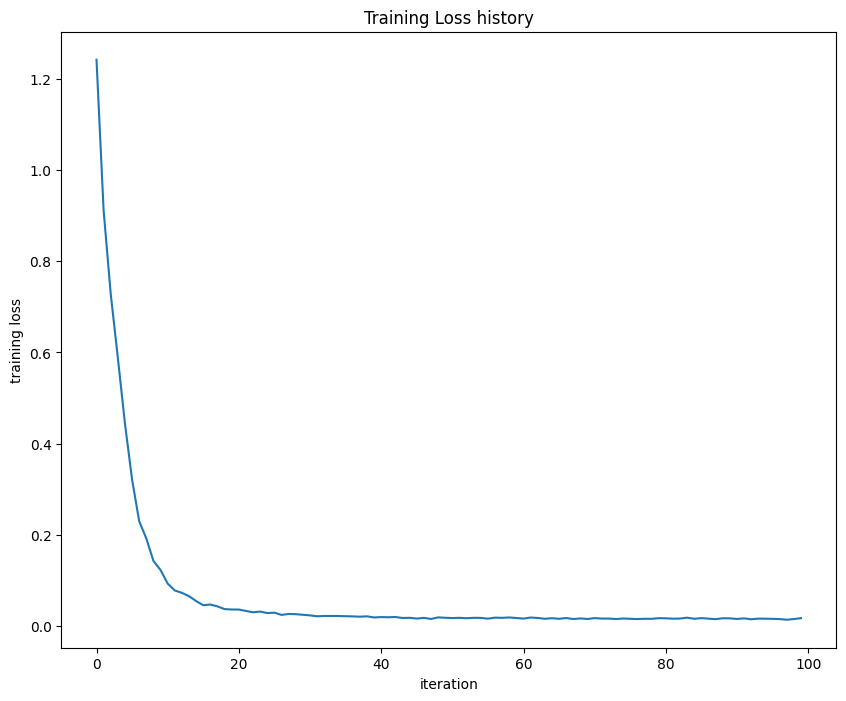

In [6]:
net = init_toy_model()
stats = net.train(X, y, X, y,
            learning_rate=1e-1, reg=5e-6,
            num_iters=100, verbose=False)

print('Final training loss: ', stats['loss_history'][-1])


plt.plot(stats['loss_history'])
plt.xlabel('iteration')
plt.ylabel('training loss')
plt.title('Training Loss history')
plt.show()

# Обучение нейронной сети на реальном наборе данных (CIFAR-10)

Загрузите набор данных, соответствующий вашему варианту. 

Разделите данные на обучающую, тестовую и валидационную выборки.

Выполните предобработку данных, как в ЛР 1. 

Обучите нейронную сеть на ваших данных. 

При сдаче лабораторной работы объясните значения всех параметров метода train.

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scripts.data_utils import load_CIFAR10 

cifar10_dir = 'scripts/datasets/cifar-10-batches-py'

try:
    del X_train, y_train
    del X_test, y_test
    print('Clear previously loaded data.')
except:
    pass

X_train, y_train, X_test, y_test = load_CIFAR10(cifar10_dir)

print('Training data shape: ', X_train.shape)
print('Training labels shape: ', y_train.shape)
print('Test data shape: ', X_test.shape)
print('Test labels shape: ', y_test.shape)

# Разделение на train/val/test
num_training = 49000
num_validation = 1000
num_test = 1000

# Валидационная выборка
mask = list(range(num_training, num_training + num_validation))
X_val = X_train[mask]  
y_val = y_train[mask]  

# Обучающая выборка
mask = list(range(num_training))
X_train = X_train[mask]    
y_train = y_train[mask]  

# Тестовая выборка
mask = list(range(num_test))
X_test = X_test[mask]  
y_test = y_test[mask]

X_train = np.reshape(X_train, (X_train.shape[0], -1))
X_val = np.reshape(X_val, (X_val.shape[0], -1))
X_test = np.reshape(X_test, (X_test.shape[0], -1))


mean_image = np.mean(X_train, axis=0)
X_train -= mean_image
X_val -= mean_image
X_test -= mean_image

print('Train data shape: ', X_train.shape)
print('Train labels shape: ', y_train.shape)
print('Validation data shape: ', X_val.shape)
print('Validation labels shape: ', y_val.shape)
print('Test data shape: ', X_test.shape)
print('Test labels shape: ', y_test.shape)

Training data shape:  (50000, 32, 32, 3)
Training labels shape:  (50000,)
Test data shape:  (10000, 32, 32, 3)
Test labels shape:  (10000,)
Train data shape:  (49000, 3072)
Train labels shape:  (49000,)
Validation data shape:  (1000, 3072)
Validation labels shape:  (1000,)
Test data shape:  (1000, 3072)
Test labels shape:  (1000,)


In [8]:
input_size = 32 * 32 * 3
hidden_size = 50
num_classes = 10
net = TwoLayerNet(input_size, hidden_size, num_classes)

stats = net.train(X_train, y_train, X_val, y_val,
            num_iters=1000, batch_size=200,
            learning_rate=1e-4, learning_rate_decay=0.95,
            reg=0.25, verbose=True)

val_acc = (net.predict(X_val) == y_val).mean()
print('Validation accuracy: ', val_acc)

iteration 0 / 1000: loss 2.302954
iteration 100 / 1000: loss 2.302550
iteration 200 / 1000: loss 2.297648
iteration 300 / 1000: loss 2.259602
iteration 400 / 1000: loss 2.204170
iteration 500 / 1000: loss 2.118565
iteration 600 / 1000: loss 2.051535
iteration 700 / 1000: loss 1.988466
iteration 800 / 1000: loss 2.006591
iteration 900 / 1000: loss 1.951473
Validation accuracy:  0.287


Используя параметры по умолчанию, вы можете получить accuracy, примерно равный 0.29. 

Проведите настройку гиперпараметров для увеличения accuracy. Поэкспериментируйте со значениями гиперпараметров, например, с количеством скрытых слоев, количеством эпох, скорости обучения и др. Ваша цель - максимально увеличить accuracy полносвязной сети на валидационном наборе. Различные эксперименты приветствуются. Например, вы можете использовать методы для сокращения размерности признакового пространства (например, PCA), добавить dropout слои и др. 

Для лучшей модели вычислите acсuracy на тестовом наборе. 

Для отладки процесса обучения часто помогают графики изменения loss и accuracy в процессе обучения. Ниже приведен код построения таких графиков. 

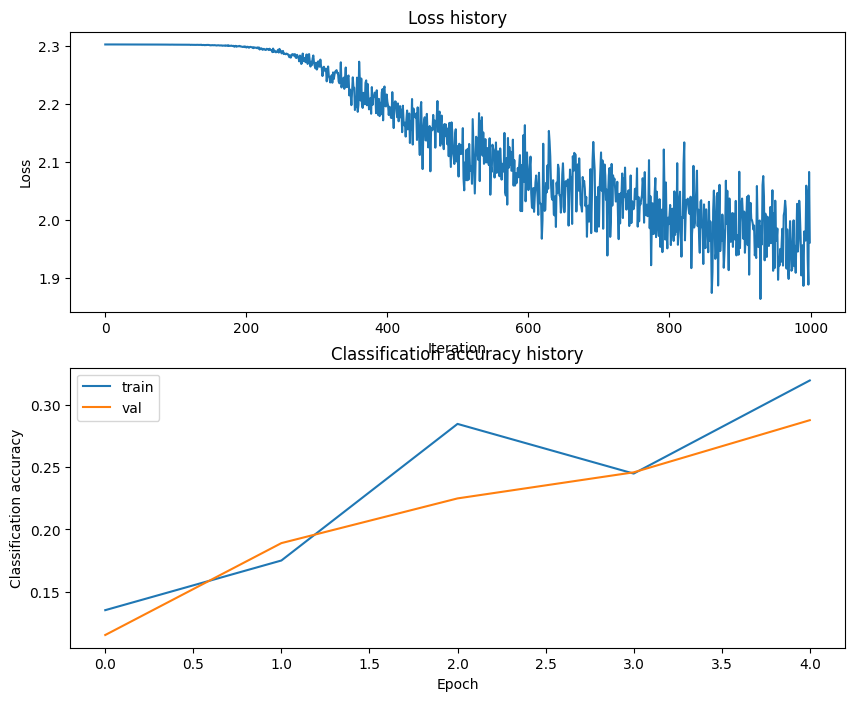

In [9]:
plt.subplot(2, 1, 1)
plt.plot(stats['loss_history'])
plt.title('Loss history')
plt.xlabel('Iteration')
plt.ylabel('Loss')

plt.subplot(2, 1, 2)
plt.plot(stats['train_acc_history'], label='train')
plt.plot(stats['val_acc_history'], label='val')
plt.title('Classification accuracy history')
plt.xlabel('Epoch')
plt.ylabel('Classification accuracy')
plt.legend()
plt.show()

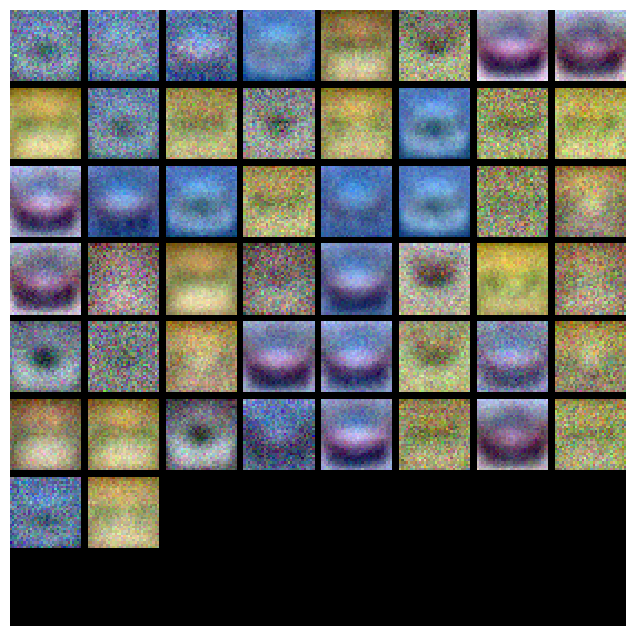

In [10]:
from scripts.vis_utils import visualize_grid

def show_net_weights(net):
    W1 = net.params['W1']
    W1 = W1.reshape(32, 32, 3, -1).transpose(3, 0, 1, 2)
    plt.imshow(visualize_grid(W1, padding=3).astype('uint8'))
    plt.gca().axis('off')
    plt.show()

show_net_weights(net)

In [11]:
hidden_sizes = [100, 200]
learning_rates = [5e-4, 1e-3]
regs = [0.25, 0.5]
batch_sizes = [256]

best_val_acc = 0
best_net = None
best_params = {}
results_list = []

X_train_sub = X_train[:20000]
y_train_sub = y_train[:20000]

for hidden_size in hidden_sizes:
    for lr in learning_rates:
        for reg in regs:
            for batch_size in batch_sizes:
                print(f"\nТестируем: hidden={hidden_size}, lr={lr}, reg={reg}, batch={batch_size}")
                
                net = TwoLayerNet(3072, hidden_size, 10)
                
                stats = net.train(
                    X_train_sub, y_train_sub,
                    X_val, y_val,
                    num_iters=1500,
                    batch_size=batch_size,
                    learning_rate=lr,
                    learning_rate_decay=0.95,
                    reg=reg,
                    verbose=False
                )
                
                val_acc = np.mean(net.predict(X_val) == y_val)
                train_acc = np.mean(net.predict(X_train_sub[:500]) == y_train_sub[:500])
                
                print(f"Train accuracy: {train_acc:.4f}, Val accuracy: {val_acc:.4f}")
                
                results_list.append({
                    'hidden_size': hidden_size,
                    'lr': lr,
                    'reg': reg,
                    'batch_size': batch_size,
                    'val_acc': val_acc,
                    'train_acc': train_acc,
                    'stats': stats
                })
                
                if val_acc > best_val_acc:
                    best_val_acc = val_acc
                    best_net = net
                    best_params = {
                        'hidden_size': hidden_size,
                        'learning_rate': lr,
                        'reg': reg,
                        'batch_size': batch_size
                    }
                    print(f"Лучший результат: {val_acc:.4f} ({val_acc*100:.2f}%)")

print("\nЛучшие параметры ")
print(f"hidden_size: {best_params['hidden_size']}")
print(f"learning_rate: {best_params['learning_rate']}")
print(f"reg: {best_params['reg']}")
print(f"batch_size: {best_params['batch_size']}")
print(f"Validation accuracy: {best_val_acc:.4f} ({best_val_acc*100:.2f}%)")


Тестируем: hidden=100, lr=0.0005, reg=0.25, batch=256
Train accuracy: 0.5300, Val accuracy: 0.4520
Лучший результат: 0.4520 (45.20%)

Тестируем: hidden=100, lr=0.0005, reg=0.5, batch=256
Train accuracy: 0.5020, Val accuracy: 0.4570
Лучший результат: 0.4570 (45.70%)

Тестируем: hidden=100, lr=0.001, reg=0.25, batch=256
Train accuracy: 0.5920, Val accuracy: 0.4620
Лучший результат: 0.4620 (46.20%)

Тестируем: hidden=100, lr=0.001, reg=0.5, batch=256
Train accuracy: 0.5760, Val accuracy: 0.4850
Лучший результат: 0.4850 (48.50%)

Тестируем: hidden=200, lr=0.0005, reg=0.25, batch=256
Train accuracy: 0.5600, Val accuracy: 0.4720

Тестируем: hidden=200, lr=0.0005, reg=0.5, batch=256
Train accuracy: 0.5260, Val accuracy: 0.4690

Тестируем: hidden=200, lr=0.001, reg=0.25, batch=256
Train accuracy: 0.6140, Val accuracy: 0.4770

Тестируем: hidden=200, lr=0.001, reg=0.5, batch=256
Train accuracy: 0.6220, Val accuracy: 0.5090
Лучший результат: 0.5090 (50.90%)

Лучшие параметры 
hidden_size: 200
le

In [12]:
# Оценка лучшей модели на тестовой выборке
test_acc = (best_net.predict(X_test) == y_test).mean()
print(f'Test accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)')

Test accuracy: 0.4850 (48.50%)


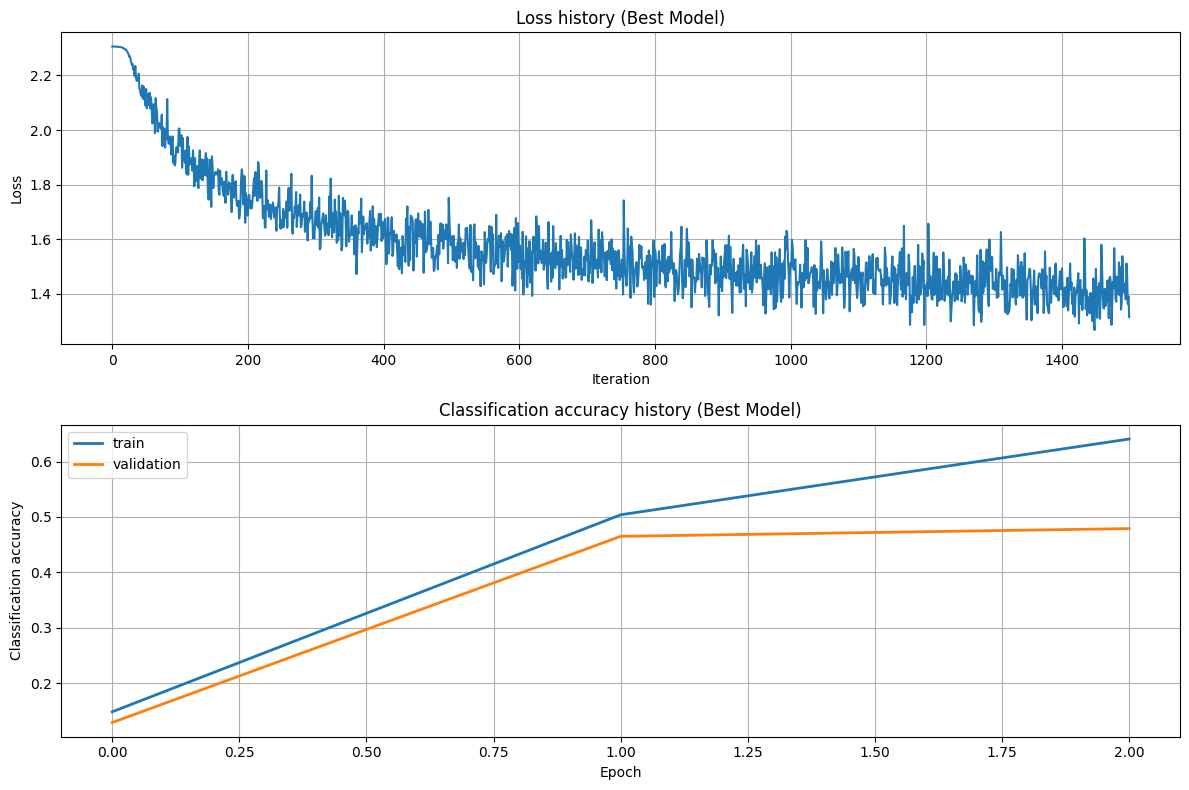

In [ ]:
best_stats = None
for result in results_list:
    if result['val_acc'] == best_val_acc:
        best_stats = result['stats']
        break

plt.figure(figsize=(12, 8))

plt.subplot(2, 1, 1)
plt.plot(best_stats['loss_history'])
plt.title('Loss history (Best Model)')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.grid(True)

plt.subplot(2, 1, 2)
if len(best_stats['train_acc_history']) > 1:
    plt.plot(best_stats['train_acc_history'], label='train', linewidth=2)
    plt.plot(best_stats['val_acc_history'], label='validation', linewidth=2)
else:
    plt.plot(best_stats['train_acc_history'], 'bo', label='train', markersize=10)
    plt.plot(best_stats['val_acc_history'], 'ro', label='validation', markersize=10)
plt.title('Classification accuracy history (Best Model)')
plt.xlabel('Epoch')
plt.ylabel('Classification accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


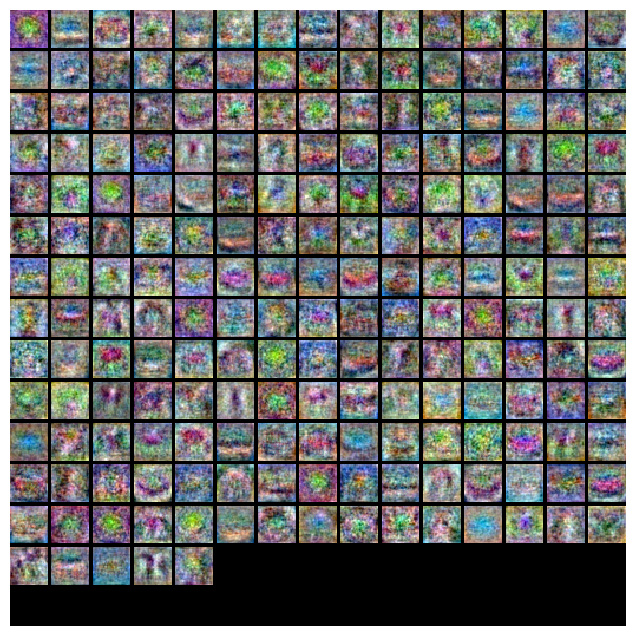

In [14]:
show_net_weights(best_net)

Сделайте выводы по результатам работы. 

В ходе выполнения лабораторной работы была реализована двухслойная полносвязная нейронная сеть с ReLU функцией активации и softmax выходным слоем. Сеть обучалась на наборе данных CIFAR-10. 

Лучшие параметры:
hidden_size: 200
learning_rate: 0.001
reg: 0.5
batch_size: 256

Validation accuracy: 50.9%
Test accuracy: 48.5%

Двухслойная нейронная сеть значительно превосходит линейные методы (kNN и Softmax) по точности классификации. Это объясняется способностью нелинейной активации (ReLU) моделировать сложные зависимости в данных.
Можно сделать вывод, что подбор гиперпараметров значительно влияет на качество модели.